# Score Stability Experiments

这个 notebook 使用当前项目里的 `qwen3_ollama.py` + `src.scoring.pipeline` 评分链路，支持三个实验：

1. `data/experiments/same_pdf/` 里可以放多个 PDF；每个 PDF 默认跑 3 遍，统计每个文件自己的分数分布。
2. `data/experiments/group_a/` 和 `data/experiments/group_b/` 两组 PDF 做分布比较。
3. `whole_json_baseline` 把完整 parsed JSON 和完整 criteria 一次性喂给模型，按 criteria 直接打分。

运行结果会自动写到 `data/experiments/results/`，解析后的 JSON 会缓存在 `data/experiments/results/parsed_cache/`。

默认复用解析缓存，只重复跑 scoring。需要连 parser 随机性一起测试时，把 `reparse_each_run=True`。


In [ ]:
!pip install matplotlib

In [1]:
from __future__ import annotations

import json
import os
import sys
import time
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError:
    plt = None
    print('matplotlib is not installed; plotting helpers will be skipped.')
import pandas as pd

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from qwen3_ollama import _Scorer, score_application
from src.all_type_parser.all_type_parser import parse_and_save
from src.pool.build_pool import build_chunk_pool
from src.scoring.pipeline import (
    OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE,
    SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE,
    _aggregate_overall,
    _aggregate_section,
    _build_scored_section,
    _generate_json_with_parse_retry,
    _normalize_model_section_output,
    load_rubric,
)

CRITERIA_PATH = PROJECT_ROOT / 'criteria_points.json'
EXPERIMENT_ROOT = PROJECT_ROOT / 'data' / 'experiments'
SAME_PDF_DIR = EXPERIMENT_ROOT / 'same_pdf'
GROUP_A_DIR = EXPERIMENT_ROOT / 'group_a'
GROUP_B_DIR = EXPERIMENT_ROOT / 'group_b'
RESULTS_DIR = EXPERIMENT_ROOT / 'results'
PARSED_CACHE_DIR = RESULTS_DIR / 'parsed_cache'

DEFAULT_SAME_PDF_RUNS_PER_FILE = 3
WHOLE_JSON_BASELINE_MAX_TOKENS = int(os.environ.get('WHOLE_JSON_BASELINE_MAX_TOKENS', '32768'))
EXPERIMENT_OLLAMA_MODEL = 'qwen3.5:27b'  # 改这里即可切换实验模型，例如 'qwen3.5:35b'

for path in [SAME_PDF_DIR, GROUP_A_DIR, GROUP_B_DIR, RESULTS_DIR, PARSED_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

SECTION_KEYS = [
    'general',
    'proposed_research',
    'training_development',
    'sites_support',
    'wpcc',
    'application_form',
]
SECTION_SCORE_COLUMNS = [f'{section_key}_score_100' for section_key in SECTION_KEYS]
RUN_SCORE_COLUMNS = ['overall_score_100', *SECTION_SCORE_COLUMNS]
RUN_DISPLAY_COLUMNS = ['pdf_name', 'run_idx', *RUN_SCORE_COLUMNS, 'avg_signal_score_0to5']
GROUP_RUN_DISPLAY_COLUMNS = ['group', *RUN_DISPLAY_COLUMNS]

print('Project root:', PROJECT_ROOT)
print('Same PDF dir:', SAME_PDF_DIR)
print('Group A dir:', GROUP_A_DIR)
print('Group B dir:', GROUP_B_DIR)
print('Results dir:', RESULTS_DIR)
print('Default same-pdf runs per file:', DEFAULT_SAME_PDF_RUNS_PER_FILE)
print('Whole-json baseline max tokens:', WHOLE_JSON_BASELINE_MAX_TOKENS)
print('Experiment Ollama model:', EXPERIMENT_OLLAMA_MODEL)


Project root: d:\MSc_AI\SWE_group_project\nlp_grant_coursework
Same PDF dir: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\same_pdf
Group A dir: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\group_a
Group B dir: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\group_b
Results dir: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\results
Default same-pdf runs per file: 3
Whole-json baseline max tokens: 32768
Experiment Ollama model: qwen3.5:27b


In [2]:
def list_pdfs(folder: Path) -> list[Path]:
    return sorted([path for path in folder.glob('*.pdf') if path.is_file()])


def parse_pdf_cached(pdf_path: Path, *, reparse: bool = False) -> tuple[dict, Path]:
    json_path = PARSED_CACHE_DIR / f'{pdf_path.stem}.json'
    if reparse or not json_path.exists():
        parse_and_save(str(pdf_path), str(json_path))
    parsed = json.loads(json_path.read_text(encoding='utf-8'))
    return parsed, json_path


def make_experiment_scorer(model_name: str | None = None) -> _Scorer:
    return _Scorer(model_name=model_name or EXPERIMENT_OLLAMA_MODEL)


def score_pdf_once(
    pdf_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str,
    reparse: bool = False,
) -> dict:
    parsed, parsed_json_path = parse_pdf_cached(pdf_path, reparse=reparse)
    artifact_dir = RESULTS_DIR / run_tag
    artifact_dir.mkdir(parents=True, exist_ok=True)
    result = score_application(
        parsed,
        CRITERIA_PATH,
        doc_id=f'{pdf_path.stem}_{run_tag}',
        scorer=scorer,
        artifacts_dir=artifact_dir,
    )
    result['source_pdf'] = str(pdf_path)
    result['parsed_json'] = str(parsed_json_path)
    out_path = artifact_dir / f'{pdf_path.stem}_{run_tag}_scored.json'
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    result['result_json'] = str(out_path)
    return result


def compact_prompt_text(text: str, limit: int = 900) -> str:
    compact = ' '.join((text or '').split())
    if len(compact) <= limit:
        return compact
    return compact[:limit] + '...'


def build_baseline_chunk_index(pool_lookup: dict[str, dict[str, str]]) -> list[dict[str, str]]:
    return [
        {
            'chunk_id': chunk_id,
            'parser_section': meta.get('parser_section', ''),
            'source_path': meta.get('source_path', ''),
            'preview': compact_prompt_text(meta.get('text', '')),
        }
        for chunk_id, meta in pool_lookup.items()
    ]


def build_whole_json_baseline_schema(rubric_sections: list[dict], all_chunk_ids: list[str]) -> dict:
    chunk_id_item_schema = {'type': 'string'}
    if all_chunk_ids:
        chunk_id_item_schema['enum'] = all_chunk_ids

    section_properties = {}
    for section in rubric_sections:
        sub_properties = {}
        for sub in section['sub_criteria']:
            signal_properties = {
                signal['sid']: {'type': 'integer', 'enum': [0, 1, 2, 3, 4, 5]}
                for signal in sub['signals']
            }
            sub_properties[sub['sub_id']] = {
                'type': 'object',
                'properties': {
                    'signals': {
                        'type': 'object',
                        'properties': signal_properties,
                        'required': list(signal_properties),
                        'additionalProperties': False,
                    },
                    'used_chunk_ids': {
                        'type': 'array',
                        'items': chunk_id_item_schema,
                        'maxItems': 5,
                    },
                    'pros': {'type': 'string'},
                    'drawbacks': {'type': 'string'},
                },
                'required': ['signals', 'used_chunk_ids', 'pros', 'drawbacks'],
                'additionalProperties': False,
            }
        section_properties[section['section_key']] = {
            'type': 'object',
            'properties': sub_properties,
            'required': list(sub_properties),
            'additionalProperties': False,
        }
    return {
        'type': 'object',
        'properties': section_properties,
        'required': list(section_properties),
        'additionalProperties': False,
    }


def build_whole_json_baseline_messages(
    *,
    parsed_application: dict,
    rubric_sections: list[dict],
    pool_lookup: dict[str, dict[str, str]],
) -> list[dict[str, str]]:
    payload = {
        'task': 'one_shot_whole_parsed_json_baseline_scoring',
        'rules': [
            'Use the full parsed_application_json, criteria, and evidence_chunk_index only.',
            'Make exactly one direct score for every signal in every criterion.',
            'Score each signal as an integer from 0 to 5, where 0 means no evidence and 5 means excellent explicit evidence.',
            'Use used_chunk_ids only from evidence_chunk_index. If there is no relevant support, use an empty list and score weak or absent signals low.',
            'Pros should summarize the strongest support. Drawbacks should summarize missing, weak, inferred, or ambiguous support.',
        ],
        'criteria': rubric_sections,
        'evidence_chunk_index': build_baseline_chunk_index(pool_lookup),
        'parsed_application_json': parsed_application,
    }
    return [
        {
            'role': 'system',
            'content': (
                'You are a strict NIHR grant scoring baseline. You do not use staged retrieval, '
                'belief state, or multi-pass reasoning. Return JSON only and follow the schema exactly.'
            ),
        },
        {'role': 'user', 'content': json.dumps(payload, ensure_ascii=False, indent=2)},
    ]


def score_parsed_json_baseline_once(
    parsed_json_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str = 'whole_json_baseline',
    source_pdf: Path | None = None,
) -> dict:
    parsed_json_path = Path(parsed_json_path)
    parsed = json.loads(parsed_json_path.read_text(encoding='utf-8'))
    doc_type = (parsed.get('doc_type') or '').lower()
    excluded_sections = OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE.get(doc_type, set())
    excluded_sub_ids = SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE.get(doc_type, set())

    rubric_sections = load_rubric(CRITERIA_PATH)
    pool_data = build_chunk_pool(parsed)
    pool_lookup = pool_data['pool_lookup']
    all_chunk_ids = list(pool_lookup)
    chunk_order = {chunk_id: idx for idx, chunk_id in enumerate(all_chunk_ids)}

    messages = build_whole_json_baseline_messages(
        parsed_application=parsed,
        rubric_sections=rubric_sections,
        pool_lookup=pool_lookup,
    )
    schema = build_whole_json_baseline_schema(rubric_sections, all_chunk_ids)
    raw_response, parsed_response, retry_count = _generate_json_with_parse_retry(
        scorer,
        messages,
        schema=schema,
        max_tokens=WHOLE_JSON_BASELINE_MAX_TOKENS,
        max_retries=0,
    )

    sections = []
    for rubric_section in rubric_sections:
        section_key = rubric_section['section_key']
        raw_section = parsed_response.get(section_key, {})
        if not isinstance(raw_section, dict):
            raw_section = {}
        normalized_section = _normalize_model_section_output(raw_section, rubric_section, all_chunk_ids)
        sections.append(_build_scored_section(
            rubric_section,
            normalized_section,
            chunk_order,
            excluded_sub_ids=excluded_sub_ids,
        ))

    features = {
        section['section_key']: _aggregate_section(section, pool_lookup)
        for section in sections
    }
    section_weights = {section['section_key']: section['weight'] for section in sections}
    artifact_dir = RESULTS_DIR / run_tag
    artifact_dir.mkdir(parents=True, exist_ok=True)
    raw_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_raw.json'
    sections_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_scored_sections.json'
    out_path = artifact_dir / f'{parsed_json_path.stem}_{run_tag}_scored.json'
    raw_path.write_text(raw_response, encoding='utf-8')
    sections_path.write_text(json.dumps(sections, ensure_ascii=False, indent=2), encoding='utf-8')

    result = {
        'doc_id': f'{parsed_json_path.stem}_{run_tag}',
        'run_info': {
            'ran_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'retrieval_method': 'whole_parsed_json_one_shot_baseline',
            'scorer_model': getattr(scorer, 'model_name', 'unknown'),
        },
        'pool_size': len(pool_lookup),
        'pool_lookup': pool_lookup,
        'section_chunk_ids': pool_data['section_chunk_ids'],
        'features': features,
        'overall': _aggregate_overall(features, section_weights, excluded_sections=excluded_sections),
        'source_pdf': str(source_pdf) if source_pdf else None,
        'parsed_json': str(parsed_json_path),
        'debug': {
            'scoring_contract_version': 'whole_parsed_json_baseline_v1',
            'doc_type': doc_type or None,
            'excluded_sections': sorted(excluded_sections),
            'excluded_sub_ids': sorted(excluded_sub_ids),
            'json_retry_events': [] if retry_count == 0 else [{'stage': 'whole_json_baseline', 'retry_count': retry_count}],
            'artifacts': {
                'raw_response': str(raw_path),
                'scored_sections': str(sections_path),
            },
        },
    }
    result['result_json'] = str(out_path)
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    return result


def score_pdf_whole_json_baseline_once(
    pdf_path: Path,
    *,
    scorer: _Scorer,
    run_tag: str,
    reparse: bool = False,
) -> dict:
    _, parsed_json_path = parse_pdf_cached(pdf_path, reparse=reparse)
    return score_parsed_json_baseline_once(
        parsed_json_path,
        scorer=scorer,
        run_tag=run_tag,
        source_pdf=pdf_path,
    )


def run_whole_json_baseline_experiment(
    pdf_paths: list[Path],
    *,
    reparse: bool = False,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    assert pdf_paths, f'No PDF files found in {SAME_PDF_DIR}'
    scorer = make_experiment_scorer(model_name)
    rows = []
    for idx, pdf_path in enumerate(pdf_paths, start=1):
        run_tag = f'whole_json_baseline_{pdf_path.stem}'
        print(f'[whole_json_baseline {idx}/{len(pdf_paths)}] {pdf_path.name}')
        result = score_pdf_whole_json_baseline_once(
            pdf_path,
            scorer=scorer,
            run_tag=run_tag,
            reparse=reparse,
        )
        row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=1, group='whole_json_baseline')
        rows.append(row)
        print(f'  scores | {format_run_scores(row)}')
    df = pd.DataFrame(rows)
    summary = summarize_distribution(df, by='pdf_name')
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'whole_json_baseline_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'whole_json_baseline_summary_{timestamp}.csv', index=False)
    return df, summary


def average_signal_score(result: dict) -> float:
    scores = []
    for section in result.get('features', {}).values():
        for criterion in section.get('sub_criteria', section.get('criteria', [])):
            for signal in criterion.get('signals', []):
                scores.append(float(signal.get('score_0to5_raw', signal.get('score', 0)) or 0))
    return round(sum(scores) / len(scores), 4) if scores else 0.0


def flatten_result_row(result: dict, *, pdf_name: str, run_idx: int | None, group: str | None) -> dict:
    overall = result.get('overall', {})
    row = {
        'pdf_name': pdf_name,
        'run_idx': run_idx,
        'group': group,
        'overall_score_100': float(overall.get('final_score_0to100', 0)),
        'overall_score_10': float(overall.get('score_10', 0)),
        'quality_score_100': float(overall.get('quality_score_0to100', 0)),
        'coverage_score_100': float(overall.get('coverage_score_0to100', 0)),
        'avg_signal_score_0to5': average_signal_score(result),
        'total_items': int(overall.get('total_items', 0)),
        'signal_count': int(overall.get('signal_count', 0)),
        'good_items': int(overall.get('good_items', 0)),
        'positive_items': int(overall.get('positive_items', 0)),
        'pool_size': int(result.get('pool_size', 0)),
        'source_pdf': result.get('source_pdf'),
        'parsed_json': result.get('parsed_json'),
        'result_json': result.get('result_json'),
    }
    features = result.get('features', {})
    for section_key in SECTION_KEYS:
        section = features.get(section_key, {})
        section_overall = section.get('overall', {})
        row[f'{section_key}_score_100'] = float(section_overall.get('final_score_0to100', 0))
        row[f'{section_key}_score_10'] = float(section_overall.get('score_10', 0))
        row[f'{section_key}_quality_score_100'] = float(section_overall.get('quality_score_0to100', 0))
        row[f'{section_key}_coverage_score_100'] = float(section_overall.get('coverage_score_0to100', 0))
        row[f'{section_key}_signal_count'] = int(section_overall.get('signal_count', 0))
    return row


def score_columns(df: pd.DataFrame) -> list[str]:
    return [col for col in RUN_SCORE_COLUMNS if col in df.columns]


def score_mean_std_columns(summary: pd.DataFrame) -> list[str]:
    id_cols = [col for col in ['pdf_name', 'group'] if col in summary.columns]
    metric_cols = []
    for metric in RUN_SCORE_COLUMNS:
        for suffix in ['mean', 'std']:
            col = f'{metric}_{suffix}'
            if col in summary.columns:
                metric_cols.append(col)
    if metric_cols:
        return id_cols + metric_cols
    return [col for col in ['metric', 'mean', 'std'] if col in summary.columns]


def format_run_scores(row: dict) -> str:
    parts = [f"overall={float(row.get('overall_score_100', 0)):.1f}"]
    for section_key in SECTION_KEYS:
        col = f'{section_key}_score_100'
        parts.append(f"{section_key}={float(row.get(col, 0)):.1f}")
    return ' | '.join(parts)


def summarize_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    summary = pd.DataFrame({
        'mean': df[columns].mean(),
        'std': df[columns].std(ddof=1),
        'var': df[columns].var(ddof=1),
        'min': df[columns].min(),
        'max': df[columns].max(),
        'median': df[columns].median(),
    }).reset_index().rename(columns={'index': 'metric'})
    return summary


def summarize_distribution(df: pd.DataFrame, *, by: str = 'pdf_name') -> pd.DataFrame:
    columns = score_columns(df)
    summary = df.groupby(by)[columns].agg(['count', 'mean', 'std', 'var', 'min', 'max', 'median'])
    summary.columns = ['_'.join(col).strip('_') for col in summary.columns.to_flat_index()]
    return summary.reset_index()


def plot_same_pdf(df: pd.DataFrame, pdf_name: str) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(df['run_idx'], df['overall_score_100'], marker='o')
    axes[0].set_title(f'Overall score by run: {pdf_name}')
    axes[0].set_xlabel('Run index')
    axes[0].set_ylabel('Score / 100')
    axes[0].grid(alpha=0.3)

    axes[1].boxplot(df['overall_score_100'], vert=True)
    axes[1].set_title('Overall score distribution')
    axes[1].set_ylabel('Score / 100')
    plt.tight_layout()
    plt.show()


def plot_same_pdf_distribution(df: pd.DataFrame) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    pdf_names = sorted(df['pdf_name'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(max(14, len(pdf_names) * 2.2), 4.5))
    for pdf_name, pdf_df in df.groupby('pdf_name'):
        axes[0].plot(pdf_df['run_idx'], pdf_df['overall_score_100'], marker='o', label=pdf_name)
    axes[0].set_title('Overall score by run')
    axes[0].set_xlabel('Run index')
    axes[0].set_ylabel('Score / 100')
    axes[0].grid(alpha=0.3)
    axes[0].legend(fontsize=8)

    grouped = [df.loc[df['pdf_name'] == pdf_name, 'overall_score_100'].tolist() for pdf_name in pdf_names]
    axes[1].boxplot(grouped, tick_labels=pdf_names)
    axes[1].set_title('Overall score distribution by PDF')
    axes[1].set_ylabel('Score / 100')
    axes[1].tick_params(axis='x', labelrotation=35)
    plt.tight_layout()
    plt.show()


def plot_group_compare(df: pd.DataFrame) -> None:
    if plt is None:
        print('matplotlib is not installed; skipping plot.')
        return
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for group_name, group_df in df.groupby('group'):
        axes[0].hist(group_df['overall_score_100'], bins=min(10, max(3, len(group_df))), alpha=0.5, label=group_name)
    axes[0].set_title('Overall score distribution by group')
    axes[0].set_xlabel('Score / 100')
    axes[0].set_ylabel('Count')
    axes[0].legend()

    grouped = [group_df['overall_score_100'].tolist() for _, group_df in sorted(df.groupby('group'))]
    labels = [group_name for group_name, _ in sorted(df.groupby('group'))]
    axes[1].boxplot(grouped, tick_labels=labels)
    axes[1].set_title('Overall score boxplot')
    axes[1].set_ylabel('Score / 100')
    plt.tight_layout()
    plt.show()


def optional_stat_tests(group_a_scores: pd.Series, group_b_scores: pd.Series) -> pd.DataFrame:
    rows = []
    try:
        from scipy.stats import ks_2samp, ttest_ind
        t_stat, t_p = ttest_ind(group_a_scores, group_b_scores, equal_var=False)
        ks_stat, ks_p = ks_2samp(group_a_scores, group_b_scores)
        rows.append({'test': 'welch_ttest', 'statistic': float(t_stat), 'p_value': float(t_p)})
        rows.append({'test': 'ks_2samp', 'statistic': float(ks_stat), 'p_value': float(ks_p)})
    except Exception as exc:
        rows.append({'test': 'scipy_unavailable', 'statistic': None, 'p_value': None, 'note': str(exc)})
    return pd.DataFrame(rows)


def run_same_pdf_experiment(
    pdf_path: Path,
    *,
    n_runs: int = DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run: bool = False,
    sleep_seconds: float = 0.0,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    scorer = make_experiment_scorer(model_name)
    rows = []
    for run_idx in range(1, n_runs + 1):
        run_tag = f'same_pdf_{pdf_path.stem}_run_{run_idx:02d}'
        print(f'[{pdf_path.name}] run {run_idx}/{n_runs}')
        result = score_pdf_once(
            pdf_path,
            scorer=scorer,
            run_tag=run_tag,
            reparse=reparse_each_run,
        )
        row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group='same_pdf')
        rows.append(row)
        print(f'  scores | {format_run_scores(row)}')
        if sleep_seconds > 0:
            time.sleep(sleep_seconds)
    df = pd.DataFrame(rows)
    summary = summarize_numeric(df, score_columns(df))
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'same_pdf_{pdf_path.stem}_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'same_pdf_{pdf_path.stem}_summary_{timestamp}.csv', index=False)
    return df, summary


def run_same_pdf_distribution_experiment(
    pdf_paths: list[Path],
    *,
    runs_per_pdf: int = DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run: bool = False,
    sleep_seconds: float = 0.0,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    assert pdf_paths, f'No PDF files found in {SAME_PDF_DIR}'
    scorer = make_experiment_scorer(model_name)
    rows = []
    total_runs = len(pdf_paths) * runs_per_pdf
    completed = 0
    for pdf_path in pdf_paths:
        for run_idx in range(1, runs_per_pdf + 1):
            completed += 1
            run_tag = f'same_pdf_{pdf_path.stem}_run_{run_idx:02d}'
            print(f'[{completed}/{total_runs}] {pdf_path.name} run {run_idx}/{runs_per_pdf}')
            result = score_pdf_once(
                pdf_path,
                scorer=scorer,
                run_tag=run_tag,
                reparse=reparse_each_run,
            )
            row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group='same_pdf')
            rows.append(row)
            print(f'  scores | {format_run_scores(row)}')
            if sleep_seconds > 0:
                time.sleep(sleep_seconds)
    df = pd.DataFrame(rows)
    summary = summarize_distribution(df, by='pdf_name')
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'same_pdf_distribution_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'same_pdf_distribution_summary_{timestamp}.csv', index=False)
    return df, summary


def run_group_compare_experiment(
    *,
    group_a_paths: list[Path],
    group_b_paths: list[Path],
    runs_per_pdf: int = 1,
    reparse_each_run: bool = False,
    model_name: str | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    scorer = make_experiment_scorer(model_name)
    rows = []
    for group_name, pdf_paths in [('group_a', group_a_paths), ('group_b', group_b_paths)]:
        for pdf_path in pdf_paths:
            for run_idx in range(1, runs_per_pdf + 1):
                run_tag = f'{group_name}_{pdf_path.stem}_run_{run_idx:02d}'
                print(f'[{group_name}] {pdf_path.name} run {run_idx}/{runs_per_pdf}')
                result = score_pdf_once(
                    pdf_path,
                    scorer=scorer,
                    run_tag=run_tag,
                    reparse=reparse_each_run,
                )
                row = flatten_result_row(result, pdf_name=pdf_path.name, run_idx=run_idx, group=group_name)
                rows.append(row)
                print(f'  scores | {format_run_scores(row)}')
    df = pd.DataFrame(rows)
    score_cols = score_columns(df)
    summary = df.groupby('group')[score_cols].agg(['count', 'mean', 'std', 'var', 'min', 'max', 'median'])
    summary.columns = ['_'.join(col).strip('_') for col in summary.columns.to_flat_index()]
    summary = summary.reset_index()
    tests = optional_stat_tests(
        df.loc[df['group'] == 'group_a', 'overall_score_100'],
        df.loc[df['group'] == 'group_b', 'overall_score_100'],
    )
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'group_compare_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'group_compare_summary_{timestamp}.csv')
    tests.to_csv(RESULTS_DIR / f'group_compare_tests_{timestamp}.csv', index=False)
    return df, summary, tests


## 实验 1：`same_pdf` 目录内多个 PDF，每个跑 3 遍

把一个或多个 PDF 放到 `data/experiments/same_pdf/`。下面这个 cell 会对目录里的每个 PDF 默认跑 3 遍，并输出每个 PDF 的分数分布。


In [ ]:
same_pdf_files = list_pdfs(SAME_PDF_DIR)
assert same_pdf_files, f'请在 {SAME_PDF_DIR} 里至少放 1 个 PDF。'

same_pdf_df, same_pdf_summary = run_same_pdf_distribution_experiment(
    same_pdf_files,
    runs_per_pdf=DEFAULT_SAME_PDF_RUNS_PER_FILE,
    reparse_each_run=False,
    sleep_seconds=0.0,
)

display(same_pdf_df[RUN_DISPLAY_COLUMNS])
display(same_pdf_summary[score_mean_std_columns(same_pdf_summary)])
plot_same_pdf_distribution(same_pdf_df)


[qwen3_ollama] using http://127.0.0.1:11434 model=qwen3.5:27b
[1/6] IC00001_DF_Doctoral.pdf run 1/3
[all_type_parser] ✓ fellowships_parser succeeded
[all_type_parser] saved → d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\results\parsed_cache\IC00001_DF_Doctoral.json
  scores | overall=91.2 | general=93.0 | proposed_research=97.5 | training_development=86.7 | sites_support=95.0 | wpcc=90.0 | application_form=85.0
[2/6] IC00001_DF_Doctoral.pdf run 2/3
  scores | overall=88.1 | general=92.0 | proposed_research=94.6 | training_development=80.0 | sites_support=95.0 | wpcc=82.2 | application_form=85.0
[3/6] IC00001_DF_Doctoral.pdf run 3/3


## 实验 2：两组 PDF 分布比较

把两组 PDF 分别放到：

- `data/experiments/group_a/`
- `data/experiments/group_b/`

建议每组 5 个。默认每个 PDF 跑 1 次。

In [ ]:
group_a_files = list_pdfs(GROUP_A_DIR)
group_b_files = list_pdfs(GROUP_B_DIR)

assert len(group_a_files) == 5, f'请在 {GROUP_A_DIR} 里放 5 个 PDF，当前有 {len(group_a_files)} 个。'
assert len(group_b_files) == 5, f'请在 {GROUP_B_DIR} 里放 5 个 PDF，当前有 {len(group_b_files)} 个。'

group_df, group_summary, group_tests = run_group_compare_experiment(
    group_a_paths=group_a_files,
    group_b_paths=group_b_files,
    runs_per_pdf=1,
    reparse_each_run=False,
)

display(group_df[GROUP_RUN_DISPLAY_COLUMNS])
display(group_summary[score_mean_std_columns(group_summary)])
display(group_tests)
plot_group_compare(group_df)


比较before和after的得分，各五个

In [3]:
GROUP_A_DIR = PROJECT_ROOT / 'data' / 'before'
GROUP_B_DIR = PROJECT_ROOT / 'data' / 'after'

[qwen3_ollama] using http://127.0.0.1:11434 model=qwen3.5:27b
[group_a] IC00351_before.pdf run 1/1
  scores | overall=85.5 | general=96.0 | proposed_research=77.5 | training_development=86.7 | sites_support=86.2 | wpcc=93.3 | application_form=73.3
[group_a] IC00355_before.pdf run 1/1
[all_type_parser] all PDF parsers returned empty — falling back to LLM
[all_type_parser] falling back to LLM parser (glm-ocr + qwen3.5:27b)
[llm_fallback_parser] processing: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\before\IC00355_before.pdf
[llm_fallback_parser] avg chars/page: 2393
[llm_fallback_parser] sending 102,980 chars to qwen3.5:27b …
[llm_fallback_parser] JSON parse error: Unterminated string starting at: line 9 column 17 (char 45946)
[llm_fallback_parser] raw LLM output length: 58779 and the num_predict is: 12872
[llm_fallback_parser] raw LLM output (first 500 chars): {
  "Application Title": "Transforming care for people with peripheral artery disease through community interventions

,group,pdf_name,run_idx,overall_score_100,general_score_100,proposed_research_score_100,training_development_score_100,sites_support_score_100,wpcc_score_100,application_form_score_100,avg_signal_score_0to5
0,group_a,IC00351_before.pdf,1,85.5,96.0,77.5,86.7,86.2,93.3,73.3,4.2232
1,group_a,IC00355_before.pdf,1,50.3,82.3,31.2,0.0,75.0,33.3,80.0,2.5268
2,group_a,IC00361_before.pdf,1,42.5,30.0,64.2,0.0,26.2,61.1,73.3,2.2589
3,group_a,IC00362_before.pdf,1,85.6,83.0,90.0,93.3,85.0,78.9,83.3,4.3482
4,group_a,IC00364_before.pdf,1,84.9,95.0,85.0,86.7,86.2,70.0,86.7,4.1429
5,group_b,IC00351_after.pdf,1,88.9,96.0,93.8,85.0,98.8,80.0,80.0,4.4821
6,group_b,IC00355_after.pdf,1,7.8,0.0,0.0,0.0,0.0,0.0,46.7,0.2143
7,group_b,IC00361_after.pdf,1,88.5,92.0,92.1,85.0,85.0,87.8,89.4,4.3393
8,group_b,IC00362_after.pdf,1,92.6,100.0,97.5,93.3,87.5,92.2,85.0,4.7054
9,group_b,IC00364_after.pdf,1,89.8,90.0,97.5,80.0,100.0,91.1,80.0,4.4018


,group,overall_score_100_mean,overall_score_100_std,general_score_100_mean,general_score_100_std,proposed_research_score_100_mean,proposed_research_score_100_std,training_development_score_100_mean,training_development_score_100_std,sites_support_score_100_mean,sites_support_score_100_std,wpcc_score_100_mean,wpcc_score_100_std,application_form_score_100_mean,application_form_score_100_std
0,group_a,69.76,21.503907,77.26,27.192609,69.58,23.555509,53.34,48.767028,71.72,25.877249,67.32,22.429267,79.32,5.984313
1,group_b,73.52,36.773455,75.60,42.435834,76.18,42.650873,68.66,38.677875,74.26,42.041503,70.22,39.543166,76.22,16.961781


,test,statistic,p_value
0,welch_ttest,-0.197365,0.849617
1,ks_2samp,0.800000,0.079365


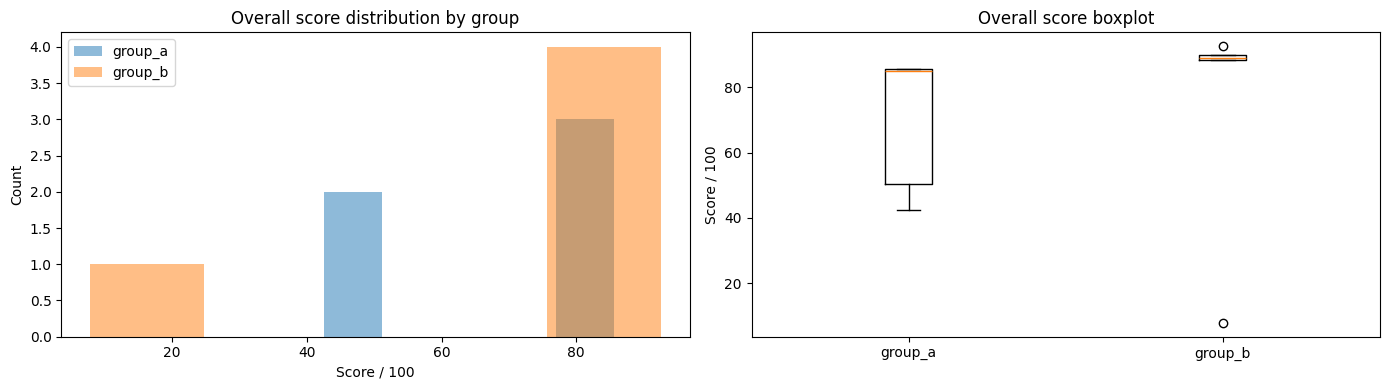

In [5]:
group_a_files = list_pdfs(GROUP_A_DIR)
group_b_files = list_pdfs(GROUP_B_DIR)

assert len(group_a_files) == 5, f'请在 {GROUP_A_DIR} 里放 5 个 PDF，当前有 {len(group_a_files)} 个。'
assert len(group_b_files) == 5, f'请在 {GROUP_B_DIR} 里放 5 个 PDF，当前有 {len(group_b_files)} 个。'

group_df, group_summary, group_tests = run_group_compare_experiment(
    group_a_paths=group_a_files,
    group_b_paths=group_b_files,
    runs_per_pdf=1,
    reparse_each_run=False,
)

display(group_df[GROUP_RUN_DISPLAY_COLUMNS])
display(group_summary[score_mean_std_columns(group_summary)])
display(group_tests)
plot_group_compare(group_df)

## 实验 3：Baseline —— 整个 parsed JSON 直接单次调用 LLM 打分（sub-criterion 级别）

**目的**：与实验 1（pipeline 多阶段打分）对比，评估两阶段流水线相对于最朴素 baseline 的增益。

**方法**：
- 不做任何预处理（无 chunking、无 Stage 1 证据检索、无分 section 调用）
- 把完整 parsed JSON + `criteria_points.json` 的所有 sub-criteria 定义（含各 signal 文本作为参考）一次性喂给 LLM
- LLM 对**每个 sub-criterion** 直接输出 0–10 的分数（signal 仅作为评分参考，不单独打分）
- 聚合逻辑与 pipeline 保持一致：sub-criterion（0–10）→ section（0–100）→ overall（0–100）
- 与实验 1 在 overall 和 section 两个层级做并排比较
- 每个 PDF 跑多次（默认 3 次）以观察 LLM 打分的稳定性

In [3]:
# ── 实验 3 helpers ──────────────────────────────────────────────────────────
from src.scoring.pipeline import (
    load_rubric,
    OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE,
    SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE,
)

BASELINE_NUM_CTX = 49152   # Ollama context window (tokens). Increase if scores are all 0.


class _BaselineScorer:
    """Thin wrapper that injects num_ctx into every Ollama request."""

    def __init__(self, model_name: str = EXPERIMENT_OLLAMA_MODEL, num_ctx: int = BASELINE_NUM_CTX):
        from qwen3_ollama import OLLAMA_HOST, OLLAMA_TIMEOUT
        import requests as _requests
        self.model_name = model_name
        self.num_ctx = num_ctx
        self._host = OLLAMA_HOST
        self._timeout = OLLAMA_TIMEOUT
        self._requests = _requests
        self.last_response_body = None
        print(f'[baseline] model={model_name}  num_ctx={num_ctx}', flush=True)

    def generate_json(self, messages: list, *, schema: dict, max_tokens: int) -> str:
        import re as _re
        payload = {
            'model': self.model_name,
            'messages': messages,
            'stream': False,
            'format': schema,
            'options': {
                'temperature': 0.1,
                'top_p': 0.9,
                'num_predict': max_tokens,
                'num_ctx': self.num_ctx,
            },
            'think': False,
        }
        try:
            resp = self._requests.post(
                f'{self._host}/api/chat', json=payload, timeout=self._timeout,
            )
        except self._requests.exceptions.ConnectionError as exc:
            raise RuntimeError(f'Could not connect to Ollama at {self._host}.') from exc
        except self._requests.exceptions.Timeout as exc:
            raise RuntimeError('Timed out waiting for Ollama.') from exc
        resp.raise_for_status()
        body = resp.json()
        self.last_response_body = body
        message = body.get('message') or {}
        content = _re.sub(
            r'<think>.*?</think>\s*', '', message.get('content') or '', flags=_re.DOTALL,
        ).strip()
        first, last = content.find('{'), content.rfind('}')
        return content[first:last + 1] if first != -1 and last > first else content


BASELINE_SECTION_KEYS = [
    'general', 'proposed_research', 'training_development',
    'sites_support', 'wpcc', 'application_form',
]


# ── Schema: sub-criterion level only (0-10 float) ────────────────────────────
def _build_baseline_sub_schema(rubric_sections: list) -> dict:
    """
    Schema constrains only sub-criterion IDs → number 0-10.
    Signals are reference only — no signal-level enforcement.
    This makes the baseline LESS constrained than the pipeline.
    """
    properties = {
        sub['sub_id']: {'type': 'number', 'minimum': 0, 'maximum': 10}
        for sec in rubric_sections
        for sub in sec['sub_criteria']
    }
    return {
        'type': 'object',
        'properties': properties,
        'required': list(properties.keys()),
        'additionalProperties': False,
    }


# ── Prompt: image-style, subcriteria 0-10, signals as reference ──────────────
def _format_criteria_for_prompt(rubric_sections: list) -> str:
    """Format all sub-criteria and their signals as readable reference text."""
    lines = []
    for section in rubric_sections:
        lines.append(f"\n=== {section['human_name']} ===")
        for sub in section['sub_criteria']:
            lines.append(f"  [{sub['sub_id']}] {sub['name']}")
            lines.append(f"  Definition: {sub['definition']}")
            for sig in sub['signals']:
                lines.append(f"    - {sig['text']}")
    return '\n'.join(lines)


def _build_baseline_messages(parsed_app: dict, rubric_sections: list) -> list:
    """
    Image-style prompt: score each sub-criterion 0-10, use signals as reference.
    Less constrained than pipeline: no section-by-section decomposition,
    no evidence retrieval, single call for the entire application.
    """
    criteria_text = _format_criteria_for_prompt(rubric_sections)
    all_sub_ids = [
        sub['sub_id']
        for sec in rubric_sections
        for sub in sec['sub_criteria']
    ]
    if_applicable_subs = [
        sub['sub_id']
        for sec in rubric_sections
        for sub in sec['sub_criteria']
        if 'if applicable' in f"{sub.get('name','')} {sub.get('definition','')}".lower()
    ]
    system = (
        'You are an expert grant application reviewer.\n'
        'Score the grant application according to the scoring rubric below.\n'
        'For each sub-criterion, assign a score from 0 to 10.\n'
        'Use the signals listed under each sub-criterion as reference '
        'when deciding the score — do NOT score each signal individually.\n'
        'Sub-criteria marked as "if applicable" that do not apply to this '
        'application should receive a score of -1 to indicate N/A.\n'
        'Return JSON only.\n'
        'Structure: top-level keys are sub-criterion IDs, values are numbers (0-10, or -1 for N/A).\n'
        f'Required keys: {all_sub_ids}\n'
        f'Potentially N/A sub-criteria: {if_applicable_subs}'
    )
    user = (
        'SCORING RUBRIC (signals are reference only — score at sub-criterion level):\n'
        + criteria_text
        + '\n\nGRANT APPLICATION:\n'
        + json.dumps(parsed_app, ensure_ascii=False, indent=2)
        + '\n\nReturn a JSON object mapping each sub-criterion ID to its 0-10 score '
        '(or -1 if not applicable).'
    )
    return [
        {'role': 'system', 'content': system},
        {'role': 'user', 'content': user},
    ]


# ── Aggregation: sub-level input, same section/overall math as pipeline ───────
def _aggregate_baseline(raw_scores: dict, rubric_sections: list, doc_type: str = '') -> tuple:
    """
    raw_scores: {sub_id: float(0-10)}  (-1 means N/A, excluded from average)
    Aggregation mirrors pipeline _aggregate_section / _aggregate_overall:
      sub score_10 (weighted) → section score_10 → overall score_10
    """
    dt = doc_type.lower()
    excluded_sections = OVERALL_EXCLUDED_SECTIONS_BY_DOC_TYPE.get(dt, set())
    excluded_sub_ids  = SECTION_EXCLUDED_SUB_IDS_BY_DOC_TYPE.get(dt, set())

    features = {}
    all_sub_scores = []

    for section in rubric_sections:
        section_key = section['section_key']
        sub_results = []

        for sub in section['sub_criteria']:
            sub_id = sub['sub_id']
            raw_val = raw_scores.get(sub_id, 0)
            # -1 = N/A (LLM flagged as not applicable)
            is_na = isinstance(raw_val, (int, float)) and raw_val < 0
            score_10 = 0.0 if is_na else round(max(0.0, min(10.0, float(raw_val))), 2)
            is_doc_excluded = sub_id in excluded_sub_ids
            counts = not is_na and not is_doc_excluded
            sub_results.append({
                'sub_id': sub_id,
                'name': sub['name'],
                'weight': sub['weight'],
                'score_10': score_10,
                'is_na': is_na,
                'counts_toward_section_average': counts,
            })
            if counts:
                all_sub_scores.append(score_10)

        # section score: same formula as pipeline _aggregate_section
        scored = [s for s in sub_results if s['counts_toward_section_average']] or sub_results
        total_w = sum(s['weight'] for s in scored) or 1.0
        section_score_10 = round(
            sum(s['score_10'] * s['weight'] for s in scored) / total_w, 2
        )
        positive_items = sum(1 for s in scored if s['score_10'] > 0)

        features[section_key] = {
            'score_10': section_score_10,
            'weight': section['weight'],
            'sub_criteria': sub_results,
            'overall': {
                'score_10': section_score_10,
                'final_score_0to100': round(section_score_10 * 10, 2),
                'positive_items': positive_items,
                'scored_items': len(scored),
                'total_items': len(sub_results),
                'signal_count': sum(len(sub['signals']) for sub in section['sub_criteria']),
            },
        }

    # overall: same formula as pipeline _aggregate_overall
    scoring_features = {
        k: v for k, v in features.items() if k not in excluded_sections
    } or features
    section_weights = {k: v['weight'] for k, v in features.items()}
    total_w = sum(section_weights.get(k, 1.0) for k in scoring_features) or 1.0
    overall_10 = round(
        sum(features[k]['score_10'] * section_weights.get(k, 1.0) for k in scoring_features) / total_w, 2
    )
    overall = {
        'score_10': overall_10,
        'final_score_0to100': round(overall_10 * 10, 2),
    }
    # avg_sub_score on 0-5 scale for comparison with pipeline's avg_signal_score_0to5
    avg_sub_as_signal = round(sum(all_sub_scores) / len(all_sub_scores) / 2, 4) if all_sub_scores else 0.0
    return features, overall, avg_sub_as_signal


# ── Scoring entry point ───────────────────────────────────────────────────────
def baseline_score_pdf_once(
    pdf_path: Path,
    *,
    scorer,
    run_tag: str,
    reparse: bool = False,
    criteria_path: Path = CRITERIA_PATH,
) -> dict:
    """parse（带缓存）→ 单次 LLM 调用（sub-criterion 级分数）→ pipeline 相同的聚合逻辑。"""
    parsed, parsed_json_path = parse_pdf_cached(pdf_path, reparse=reparse)
    rubric_sections = load_rubric(criteria_path)
    doc_type = (parsed.get('doc_type') or '').lower()

    messages = _build_baseline_messages(parsed, rubric_sections)
    schema   = _build_baseline_sub_schema(rubric_sections)
    raw = scorer.generate_json(messages, schema=schema, max_tokens=1024)

    try:
        raw_scores = json.loads(raw)
    except json.JSONDecodeError:
        import re as _re
        m = _re.search(r'\{.*\}', raw, _re.DOTALL)
        raw_scores = json.loads(m.group()) if m else {}

    features, overall, avg_sub = _aggregate_baseline(raw_scores, rubric_sections, doc_type)

    artifact_dir = RESULTS_DIR / run_tag
    artifact_dir.mkdir(parents=True, exist_ok=True)
    out_path = artifact_dir / f'{pdf_path.stem}_{run_tag}_baseline.json'
    result = {
        'doc_id': f'{pdf_path.stem}_{run_tag}',
        'source_pdf': str(pdf_path),
        'parsed_json': str(parsed_json_path),
        'features': features,
        'overall': overall,
        'avg_signal_score_0to5': avg_sub,  # avg sub score converted to 0-5 for comparison
        'raw_sub_scores': raw_scores,
        'raw_llm_response': raw,
    }
    out_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    result['result_json'] = str(out_path)
    return result


def flatten_baseline_row(result: dict, *, pdf_name: str, run_idx: int) -> dict:
    overall  = result.get('overall', {})
    features = result.get('features', {})
    row = {
        'pdf_name': pdf_name,
        'run_idx': run_idx,
        'overall_score_100': float(overall.get('final_score_0to100', 0)),
        'avg_signal_score_0to5': float(result.get('avg_signal_score_0to5', 0)),
        'source_pdf': result.get('source_pdf'),
        'result_json': result.get('result_json'),
    }
    for key in BASELINE_SECTION_KEYS:
        sec = features.get(key, {})
        row[f'{key}_score_100'] = float(sec.get('overall', {}).get('final_score_0to100', 0))
    return row


def run_baseline_experiment(
    pdf_paths: list,
    *,
    runs_per_pdf: int = 3,
    reparse_each_run: bool = False,
    model_name: str | None = None,
) -> tuple:
    """对 same_pdf 目录里的 PDF 跑 baseline，每个 PDF 跑 runs_per_pdf 遍。"""
    assert pdf_paths, 'No PDF files found.'
    scorer = _BaselineScorer(model_name=model_name or EXPERIMENT_OLLAMA_MODEL)
    rows = []
    total = len(pdf_paths) * runs_per_pdf
    completed = 0
    for pdf_path in pdf_paths:
        for run_idx in range(1, runs_per_pdf + 1):
            completed += 1
            run_tag = f'baseline_{pdf_path.stem}_run_{run_idx:02d}'
            print(f'[baseline {completed}/{total}] {pdf_path.name} run {run_idx}/{runs_per_pdf}')
            result = baseline_score_pdf_once(
                pdf_path, scorer=scorer, run_tag=run_tag, reparse=reparse_each_run,
            )
            row = flatten_baseline_row(result, pdf_name=pdf_path.name, run_idx=run_idx)
            rows.append(row)
            section_parts = ' | '.join(
                f'{k}={row[f"{k}_score_100"]:.1f}' for k in BASELINE_SECTION_KEYS
            )
            print(f"  overall={row['overall_score_100']:.1f} | avg_sub(0-5)={row['avg_signal_score_0to5']:.2f}")
            print(f'  sections: {section_parts}')

    df = pd.DataFrame(rows)
    score_cols = ['overall_score_100', 'avg_signal_score_0to5'] + [
        f'{k}_score_100' for k in BASELINE_SECTION_KEYS
    ]
    summary = summarize_numeric(df, score_cols)
    timestamp = pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')
    df.to_csv(RESULTS_DIR / f'baseline_runs_{timestamp}.csv', index=False)
    summary.to_csv(RESULTS_DIR / f'baseline_summary_{timestamp}.csv', index=False)
    return df, summary


def compare_pipeline_vs_baseline(pipeline_df: pd.DataFrame, baseline_df: pd.DataFrame) -> pd.DataFrame:
    """并排比较 pipeline（实验1）和 baseline（实验3）在同一组 PDF 上的均值分数。"""
    score_cols = ['overall_score_100', 'avg_signal_score_0to5'] + [
        f'{k}_score_100' for k in BASELINE_SECTION_KEYS
    ]
    p_rename = {c: f'pipeline_{c}' for c in score_cols}
    b_rename = {c: f'baseline_{c}' for c in score_cols}
    p_mean = pipeline_df.groupby('pdf_name')[
        [c for c in score_cols if c in pipeline_df.columns]
    ].mean().rename(columns=p_rename)
    b_mean = baseline_df.groupby('pdf_name')[
        [c for c in score_cols if c in baseline_df.columns]
    ].mean().rename(columns=b_rename)
    merged = p_mean.join(b_mean, how='outer')
    for c in score_cols:
        pc, bc = f'pipeline_{c}', f'baseline_{c}'
        if pc in merged.columns and bc in merged.columns:
            merged[f'diff_{c}'] = merged[pc] - merged[bc]
    return merged.reset_index()


def summarize_per_pdf(df: pd.DataFrame) -> pd.DataFrame:
    """对每个 PDF 分别统计多次 baseline 运行的 mean / std / min / max。"""
    score_cols = ['overall_score_100', 'avg_signal_score_0to5'] + [
        f'{k}_score_100' for k in BASELINE_SECTION_KEYS
    ]
    available = [c for c in score_cols if c in df.columns]
    agg = df.groupby('pdf_name')[available].agg(['mean', 'std', 'min', 'max'])
    agg.columns = ['_'.join(col) for col in agg.columns]
    return agg.reset_index()


In [13]:
# ── 实验 3 运行 ──────────────────────────────────────────────────────────────
# 与实验 1 使用相同模型和相同跑数，确保对比公平。
# 复用实验 1 的 parsed 缓存，仅重新调用 LLM。
# num_ctx 由 BASELINE_NUM_CTX 控制（默认 32768），可在 cell 9 顶部修改。
BASELINE_MODEL        = EXPERIMENT_OLLAMA_MODEL
BASELINE_RUNS_PER_PDF = DEFAULT_SAME_PDF_RUNS_PER_FILE

same_pdf_files = list_pdfs(SAME_PDF_DIR)
assert same_pdf_files, f'请在 {SAME_PDF_DIR} 里至少放 1 个 PDF。'

baseline_df, _ = run_baseline_experiment(
    same_pdf_files,
    runs_per_pdf=BASELINE_RUNS_PER_PDF,
    reparse_each_run=False,
    model_name=BASELINE_MODEL,
)

BASELINE_DISPLAY_COLS = [
    'pdf_name', 'run_idx', 'overall_score_100', 'avg_signal_score_0to5',
] + [f'{k}_score_100' for k in BASELINE_SECTION_KEYS]

print('\n── Baseline 各次运行分数 ──')
display(baseline_df[BASELINE_DISPLAY_COLS])

print('\n── Baseline 每个 PDF 的跨运行统计（mean / std / min / max）──')
baseline_per_pdf_summary = summarize_per_pdf(baseline_df)
display(baseline_per_pdf_summary)


[baseline] model=qwen3.5:27b  num_ctx=49152
[baseline 1/6] IC00001_DF_Doctoral.pdf run 1/3
  overall=89.8 | avg_sub(0-5)=4.45
  sections: general=88.3 | proposed_research=87.8 | training_development=90.0 | sites_support=97.5 | wpcc=85.0 | application_form=90.0
[baseline 2/6] IC00001_DF_Doctoral.pdf run 2/3
  overall=90.9 | avg_sub(0-5)=4.48
  sections: general=88.3 | proposed_research=87.8 | training_development=96.7 | sites_support=97.5 | wpcc=85.0 | application_form=90.0
[baseline 3/6] IC00001_DF_Doctoral.pdf run 3/3
  overall=88.5 | avg_sub(0-5)=4.40
  sections: general=88.3 | proposed_research=86.7 | training_development=90.0 | sites_support=97.5 | wpcc=85.0 | application_form=83.3
[baseline 4/6] IC00147_after.pdf run 1/3
  overall=89.2 | avg_sub(0-5)=4.45
  sections: general=90.0 | proposed_research=87.8 | training_development=90.0 | sites_support=97.5 | wpcc=86.7 | application_form=83.3
[baseline 5/6] IC00147_after.pdf run 2/3
  overall=89.2 | avg_sub(0-5)=4.45
  sections: genera

,pdf_name,run_idx,overall_score_100,avg_signal_score_0to5,general_score_100,proposed_research_score_100,training_development_score_100,sites_support_score_100,wpcc_score_100,application_form_score_100
0,IC00001_DF_Doctoral.pdf,1,89.8,4.4516,88.3,87.8,90.0,97.5,85.0,90.0
1,IC00001_DF_Doctoral.pdf,2,90.9,4.4839,88.3,87.8,96.7,97.5,85.0,90.0
2,IC00001_DF_Doctoral.pdf,3,88.5,4.4032,88.3,86.7,90.0,97.5,85.0,83.3
3,IC00147_after.pdf,1,89.2,4.4516,90.0,87.8,90.0,97.5,86.7,83.3
4,IC00147_after.pdf,2,89.2,4.4516,90.0,87.8,90.0,97.5,86.7,83.3
5,IC00147_after.pdf,3,91.2,4.5484,90.0,90.0,96.7,97.5,90.0,83.3



── Baseline 每个 PDF 的跨运行统计（mean / std / min / max）──


,pdf_name,overall_score_100_mean,overall_score_100_std,overall_score_100_min,overall_score_100_max,avg_signal_score_0to5_mean,avg_signal_score_0to5_std,avg_signal_score_0to5_min,avg_signal_score_0to5_max,general_score_100_mean,...,sites_support_score_100_min,sites_support_score_100_max,wpcc_score_100_mean,wpcc_score_100_std,wpcc_score_100_min,wpcc_score_100_max,application_form_score_100_mean,application_form_score_100_std,application_form_score_100_min,application_form_score_100_max
0,IC00001_DF_Doctoral.pdf,89.733333,1.201388,88.5,90.9,4.446233,0.040617,4.4032,4.4839,88.3,...,97.5,97.5,85.0,0.000000,85.0,85.0,87.766667,3.868247,83.3,90.0
1,IC00147_after.pdf,89.866667,1.154701,89.2,91.2,4.483867,0.055888,4.4516,4.5484,90.0,...,97.5,97.5,87.8,1.905256,86.7,90.0,83.300000,0.000000,83.3,83.3


In [ ]:
# ── 实验 1 vs 实验 3 对比 ────────────────────────────────────────────────────
# 依赖：same_pdf_df（实验1）和 baseline_df（实验3）都已在内存中。

try:
    comparison_df = compare_pipeline_vs_baseline(same_pdf_df, baseline_df)
    print('── Pipeline（实验1）vs Baseline（实验3）均值对比 ──')
    display(comparison_df)

    if plt is not None:
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))

        # ── 图1：overall 分数对比（每个 PDF 一组柱）──────────────────────────────
        pdf_names = comparison_df['pdf_name'].tolist()
        x = list(range(len(pdf_names)))
        w = 0.35
        axes[0].bar(
            [i - w/2 for i in x], comparison_df['pipeline_overall_score_100'],
            w, label='Pipeline（实验1）', color='steelblue',
        )
        axes[0].bar(
            [i + w/2 for i in x], comparison_df['baseline_overall_score_100'],
            w, label='Baseline（实验3）', color='darkorange',
        )
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(pdf_names, rotation=30, ha='right', fontsize=8)
        axes[0].set_ylabel('Overall Score / 100')
        axes[0].set_title('Overall Score: Pipeline vs Baseline')
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)

        # ── 图2：各 section 分数差（pipeline - baseline）均值 ─────────────────────
        section_diffs = []
        for key in BASELINE_SECTION_KEYS:
            col = f'diff_{key}_score_100'
            if col in comparison_df.columns:
                section_diffs.append((key, comparison_df[col].mean()))
        if section_diffs:
            labels, vals = zip(*section_diffs)
            colors = ['steelblue' if v >= 0 else 'salmon' for v in vals]
            axes[1].bar(range(len(labels)), vals, color=colors)
            axes[1].axhline(0, color='black', linewidth=0.8)
            axes[1].set_xticks(range(len(labels)))
            axes[1].set_xticklabels(labels, rotation=35, ha='right', fontsize=8)
            axes[1].set_ylabel('Pipeline − Baseline (mean)')
            axes[1].set_title('Section-level Difference\n(+: pipeline higher)')
            axes[1].grid(axis='y', alpha=0.3)

        # ── 图3：avg_signal_score_0to5 对比 ──────────────────────────────────────
        p_sig_col = 'pipeline_avg_signal_score_0to5'
        b_sig_col = 'baseline_avg_signal_score_0to5'
        if p_sig_col in comparison_df.columns and b_sig_col in comparison_df.columns:
            axes[2].bar(
                [i - w/2 for i in x], comparison_df[p_sig_col],
                w, label='Pipeline（实验1）', color='steelblue',
            )
            axes[2].bar(
                [i + w/2 for i in x], comparison_df[b_sig_col],
                w, label='Baseline（实验3）', color='darkorange',
            )
            axes[2].set_xticks(x)
            axes[2].set_xticklabels(pdf_names, rotation=30, ha='right', fontsize=8)
            axes[2].set_ylabel('Avg Signal Score (0–5)')
            axes[2].set_title('Avg Signal Score: Pipeline vs Baseline')
            axes[2].legend()
            axes[2].grid(axis='y', alpha=0.3)
        else:
            axes[2].set_visible(False)

        plt.tight_layout()
        plt.show()

except NameError:
    print('same_pdf_df 未找到，请先运行实验 1 的 cell 以生成 same_pdf_df，再运行此对比 cell。')


## 实验 3 诊断：IC00147 分数全 0 排查

排查步骤：
1. **从已保存的 artifact 里读取原始 LLM 输出** — 看 raw_llm_response 是什么
2. **估算输入 token 数** — 判断是否超出 num_ctx
3. **重新跑单次调用** — 实时抓取 raw 输出及 Ollama 返回的 done_reason

In [9]:
# ── 诊断 1：读取已保存 artifact，查看 raw_llm_response ─────────────────────────
import glob as _glob

TARGET_PDF_STEM = 'IC00147_after'   # 修改此处可排查其他 PDF

# 找所有该 PDF 的 baseline artifact
pattern = str(RESULTS_DIR / f'**/*{TARGET_PDF_STEM}*_baseline.json')
artifact_files = sorted(_glob.glob(pattern, recursive=True))
print(f'找到 {len(artifact_files)} 个 artifact:')
for p in artifact_files:
    print(' ', p)

if artifact_files:
    latest = artifact_files[-1]
    art = json.loads(Path(latest).read_text(encoding='utf-8'))
    raw_resp = art.get('raw_llm_response', '') or art.get('raw_signal_scores', {})
    raw_sub  = art.get('raw_sub_scores', art.get('raw_signal_scores', {}))

    print(f'\n── raw_llm_response (前 2000 字符) ──')
    print(repr(str(raw_resp)[:2000]))

    print(f'\n── raw_sub_scores（解析后，共 {len(raw_sub)} 个 sub） ──')
    print(json.dumps(raw_sub, indent=2, ensure_ascii=False)[:1000])

    # 检查是否有非零分
    non_zero = {k: v for k, v in raw_sub.items() if isinstance(v, (int, float)) and v != 0}
    print(f'\n非零分 sub-criteria 数：{len(non_zero)} / {len(raw_sub)}')
    if non_zero:
        print(json.dumps(non_zero, indent=2))
    else:
        print('全部为 0 或空 — LLM 输出可能被截断或格式化失败')
else:
    print('未找到 artifact，请先运行 cell 10（实验 3）。')


找到 3 个 artifact:
  d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\results\baseline_IC00147_after_run_01\IC00147_after_baseline_IC00147_after_run_01_baseline.json
  d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\results\baseline_IC00147_after_run_02\IC00147_after_baseline_IC00147_after_run_02_baseline.json
  d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\results\baseline_IC00147_after_run_03\IC00147_after_baseline_IC00147_after_run_03_baseline.json

── raw_llm_response (前 2000 字符) ──
'{\n  "PPIE_1": 9,\n  "PPIE_2": 9,\n  "PPIE_3": -1,\n  "TRAINING_1": 10,\n  "TRAINING_2": 10,\n  "TRAINING_3": 10,\n  "BUDGET_1": 10,\n  "BUDGET_2": 10,\n  "BUDGET_3": 10,\n  "BUDGET_4": 10,\n  "BUDGET_5": 10\n}'

── raw_sub_scores（解析后，共 11 个 sub） ──
{
  "PPIE_1": 9,
  "PPIE_2": 9,
  "PPIE_3": -1,
  "TRAINING_1": 10,
  "TRAINING_2": 10,
  "TRAINING_3": 10,
  "BUDGET_1": 10,
  "BUDGET_2": 10,
  "BUDGET_3": 10,
  "BUDGET_4": 10,
  "BUDGET_5": 10
}

非零分 

In [10]:
# ── 诊断 2：估算输入 token 数，判断是否超出 num_ctx ────────────────────────────
# 用字符数 / 3.5 粗估 token 数（英文约 4 chars/token，中文约 2 chars/token）

TARGET_PDF_STEM2 = 'IC00147_after'   # 可修改

# 找对应的 parsed JSON
parsed_cache_files = sorted(
    (PARSED_CACHE_DIR / f'{TARGET_PDF_STEM2}.json').parent.glob(f'{TARGET_PDF_STEM2}*.json')
)
if not parsed_cache_files:
    print('未找到 parsed cache，请先运行一次 parse_pdf_cached 或实验 3。')
else:
    parsed_path = parsed_cache_files[0]
    parsed_app = json.loads(parsed_path.read_text(encoding='utf-8'))
    rubric_sections_diag = load_rubric(CRITERIA_PATH)
    msgs = _build_baseline_messages(parsed_app, rubric_sections_diag)

    system_chars = len(msgs[0]['content'])
    user_chars   = len(msgs[1]['content'])
    total_chars  = system_chars + user_chars
    est_tokens   = total_chars / 3.5

    print(f'system message : {system_chars:>8,} chars')
    print(f'user message   : {user_chars:>8,} chars')
    print(f'total          : {total_chars:>8,} chars')
    print(f'estimated tokens (÷3.5) : {est_tokens:>8,.0f}')
    print(f'BASELINE_NUM_CTX        : {BASELINE_NUM_CTX:>8,}')
    if est_tokens > BASELINE_NUM_CTX * 0.9:
        print('⚠️  INPUT LIKELY EXCEEDS num_ctx — increase BASELINE_NUM_CTX in cell 9!')
    else:
        print('Input appears within context window.')

    # Show parsed JSON size breakdown
    app_json_chars = len(json.dumps(parsed_app, ensure_ascii=False))
    criteria_chars = total_chars - app_json_chars
    print(f'\nBreakdown: application JSON = {app_json_chars:,} chars | criteria+prompt = {criteria_chars:,} chars')


system message :      827 chars
user message   :  148,882 chars
total          :  149,709 chars
estimated tokens (÷3.5) :   42,774
BASELINE_NUM_CTX        :   32,768
⚠️  INPUT LIKELY EXCEEDS num_ctx — increase BASELINE_NUM_CTX in cell 9!

Breakdown: application JSON = 135,238 chars | criteria+prompt = 14,471 chars


In [11]:
# ── 诊断 3：对 IC00147 重新跑单次调用，实时显示 done_reason + raw 输出 ─────────

TARGET_PDF_STEM3 = 'IC00147_after'   # 可修改

target_pdf_path = None
for p in list_pdfs(SAME_PDF_DIR):
    if TARGET_PDF_STEM3 in p.stem:
        target_pdf_path = p
        break

if target_pdf_path is None:
    print(f'{TARGET_PDF_STEM3} 不在 {SAME_PDF_DIR}，请把对应 PDF 放进去。')
else:
    diag_scorer = _BaselineScorer(model_name=EXPERIMENT_OLLAMA_MODEL)
    parsed_diag, _ = parse_pdf_cached(target_pdf_path)
    rubric_diag    = load_rubric(CRITERIA_PATH)
    messages_diag  = _build_baseline_messages(parsed_diag, rubric_diag)
    schema_diag    = _build_baseline_sub_schema(rubric_diag)

    print('Sending request to Ollama...')
    raw_diag = diag_scorer.generate_json(messages_diag, schema=schema_diag, max_tokens=1024)

    # done_reason tells us if output was cut off
    body = diag_scorer.last_response_body or {}
    done_reason   = body.get('done_reason', 'unknown')
    prompt_tokens = body.get('prompt_eval_count', 'n/a')
    gen_tokens    = body.get('eval_count', 'n/a')
    print(f'\ndone_reason    : {done_reason}')
    print(f'prompt_tokens  : {prompt_tokens}  (actual tokens sent)')
    print(f'generated tokens: {gen_tokens}')
    if done_reason == 'length':
        print('⚠️  Output was CUT OFF (done_reason=length). Increase BASELINE_NUM_CTX or max_tokens.')
    elif done_reason == 'stop':
        print('Output completed normally.')

    print(f'\n── raw LLM output ({len(raw_diag)} chars) ──')
    print(raw_diag[:3000])

    # Try parsing
    try:
        parsed_diag_scores = json.loads(raw_diag)
        non_zero_diag = {k: v for k, v in parsed_diag_scores.items() if v and v != 0}
        print(f'\nParsed OK — {len(parsed_diag_scores)} sub-criteria, {len(non_zero_diag)} non-zero')
        print(json.dumps(parsed_diag_scores, indent=2, ensure_ascii=False)[:1500])
    except json.JSONDecodeError as e:
        print(f'\nJSON parse FAILED: {e}')
        print('Raw output is not valid JSON — likely truncated or schema enforcement failed.')


[baseline] model=qwen3.5:27b  num_ctx=32768
Sending request to Ollama...

done_reason    : stop
prompt_tokens  : 32768  (actual tokens sent)
generated tokens: 78
Output completed normally.

── raw LLM output (223 chars) ──
{
  "patient_involvement_development": 9,
  "patient_involvement_implementation": 9,
  "patient_involvement_justification": -1,
  "training_and_development": 9,
  "supervision_and_support": 10,
  "budget_justification": 9
}

Parsed OK — 6 sub-criteria, 6 non-zero
{
  "patient_involvement_development": 9,
  "patient_involvement_implementation": 9,
  "patient_involvement_justification": -1,
  "training_and_development": 9,
  "supervision_and_support": 10,
  "budget_justification": 9
}


## 实验 4：与 Codex 打分对比（以 Codex 分数为参考标准）

**目的**：把 Codex 的打分视为参考标准（ground truth proxy），比较我们的 pipeline（实验1）和 baseline（实验3）与 Codex 分数的接近程度。

**流程**：
1. 将下方 **Cell B** 生成的 prompt 交给 Codex，让 Codex 对 `parsed_cache` 里的每个申请评分并保存结果 JSON
2. Codex 将结果写入 `data/experiments/results/codex_scores/` 目录
3. 运行 **Cell C / D** 加载 Codex 分数，与实验1、实验3做三方对比

In [5]:
# ── Cell B：生成并打印给 Codex 的 prompt ─────────────────────────────────────
# 运行此 cell，将输出的 prompt 完整复制给 Codex，让 Codex 执行评分任务。

CODEX_SCORES_DIR = RESULTS_DIR / 'codex_scores'
CODEX_SCORES_DIR.mkdir(parents=True, exist_ok=True)

# 读取 criteria 内容和 sub-criterion 列表，嵌入 prompt
_rubric_for_codex = load_rubric(CRITERIA_PATH)
_sub_list_for_codex = [
    {'sub_id': sub['sub_id'], 'name': sub['name'], 'definition': sub['definition'],
     'signals': [s['text'] for s in sub['signals']]}
    for sec in _rubric_for_codex
    for sub in sec['sub_criteria']
]
_all_sub_ids_for_codex = [s['sub_id'] for s in _sub_list_for_codex]
_if_applicable_for_codex = [
    s['sub_id'] for s in _sub_list_for_codex
    if 'if applicable' in f"{s['name']} {s['definition']}".lower()
]
_parsed_cache_files = sorted(PARSED_CACHE_DIR.glob('*.json'))

CODEX_PROMPT = f'''
# Grant Application Scoring Task

## Your task
Score each grant application in the parsed_cache folder using the rubric below.
For each application, output a JSON file with sub-criterion scores.

## Input files (parsed application JSONs)
Folder: {PARSED_CACHE_DIR}
Files to score:
''' + '\n'.join(f'  - {f.name}' for f in _parsed_cache_files) + f'''

## Scoring rubric
Rubric file: {CRITERIA_PATH}

For each sub-criterion listed below, assign a score from 0 to 10.
Use the signals listed under each sub-criterion as REFERENCE only —
do NOT score each signal individually; give one holistic score per sub-criterion.
Sub-criteria marked as "if applicable" that do not apply to a specific application
should receive a score of -1 (will be excluded from averages).

Sub-criteria to score ({len(_all_sub_ids_for_codex)} total):
''' + json.dumps(_sub_list_for_codex, indent=2, ensure_ascii=False) + f'''

Potentially N/A sub-criteria: {_if_applicable_for_codex}

## Output format
For EACH application file, create one output JSON file:
  Output folder : {CODEX_SCORES_DIR}
  Output filename: <application_stem>_codex.json
  Example        : IC00001_DF_Doctoral_codex.json

Each output JSON must have this exact structure:
{{
  "doc_id": "<application filename stem>",
  "sub_scores": {{
    "g.1": 8.0,
    "g.2": 7.5,
    "pr.1": 9.0,
    ... (all {len(_all_sub_ids_for_codex)} sub-criterion IDs as keys)
  }}
}}

Rules:
- Sub-criterion IDs MUST match exactly: {_all_sub_ids_for_codex}
- Scores are floats 0.0–10.0, or -1 for N/A
- Do not add extra keys
- Write one file per application
'''

print(CODEX_PROMPT)
print('\n' + '='*70)
print(f'Codex 打分结果应保存到：{CODEX_SCORES_DIR}')
print(f'每个文件命名格式：<stem>_codex.json（例：IC00001_DF_Doctoral_codex.json）')



# Grant Application Scoring Task

## Your task
Score each grant application in the parsed_cache folder using the rubric below.
For each application, output a JSON file with sub-criterion scores.

## Input files (parsed application JSONs)
Folder: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\results\parsed_cache
Files to score:
  - IC00001_DF_Doctoral.json
  - IC00147_after.json

## Scoring rubric
Rubric file: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\criteria_points.json

For each sub-criterion listed below, assign a score from 0 to 10.
Use the signals listed under each sub-criterion as REFERENCE only —
do NOT score each signal individually; give one holistic score per sub-criterion.
Sub-criteria marked as "if applicable" that do not apply to a specific application
should receive a score of -1 (will be excluded from averages).

Sub-criteria to score (31 total):
[
  {
    "sub_id": "g.1",
    "name": "Common Characteristics of Good Applications",
    "definit

In [4]:
# ── Cell C：加载 Codex 分数，与实验1/3 做三方比较 ────────────────────────────────
# ⚠️  请先让 Codex 跑完评分并把 JSON 写入 codex_scores/ 目录，再运行此 cell。

CODEX_SCORES_DIR = RESULTS_DIR / 'codex_scores'   # Codex 输出目录


def load_codex_scores(codex_dir: Path) -> pd.DataFrame:
    """读取 codex_scores/ 下所有 *_codex.json，聚合成与实验1/3相同格式的 DataFrame。"""
    rubric_sections = load_rubric(CRITERIA_PATH)
    rows = []
    codex_files = sorted(codex_dir.glob('*_codex.json'))
    if not codex_files:
        print(f'⚠️  {codex_dir} 中未找到 *_codex.json 文件。')
        print('请先让 Codex 完成评分后再运行此 cell。')
        return pd.DataFrame()

    for fpath in codex_files:
        data = json.loads(fpath.read_text(encoding='utf-8'))
        doc_id    = data.get('doc_id', fpath.stem.replace('_codex', ''))
        sub_scores = data.get('sub_scores', {})
        # 用与 baseline 相同的聚合逻辑（_aggregate_baseline 来自实验3 cell）
        doc_type = ''
        # 尝试从 parsed_cache 读取 doc_type
        parsed_cache_path = PARSED_CACHE_DIR / f'{doc_id}.json'
        if parsed_cache_path.exists():
            try:
                parsed_cached = json.loads(parsed_cache_path.read_text(encoding='utf-8'))
                doc_type = (parsed_cached.get('doc_type') or '').lower()
            except Exception:
                pass

        features, overall, avg_sub = _aggregate_baseline(sub_scores, rubric_sections, doc_type)
        row = {
            'pdf_name': f'{doc_id}.pdf',
            'overall_score_100': float(overall.get('final_score_0to100', 0)),
            'avg_signal_score_0to5': float(avg_sub),
            'codex_file': str(fpath),
        }
        for key in BASELINE_SECTION_KEYS:
            sec = features.get(key, {})
            row[f'{key}_score_100'] = float(sec.get('overall', {}).get('final_score_0to100', 0))
        rows.append(row)
        print(f"  {doc_id}: overall={row['overall_score_100']:.1f} | "
              f"avg_sub(0-5)={row['avg_signal_score_0to5']:.2f}")

    return pd.DataFrame(rows)


def compare_all_three(
    pipeline_df: pd.DataFrame,
    baseline_df: pd.DataFrame,
    codex_df: pd.DataFrame,
) -> pd.DataFrame:
    """三方对比：pipeline vs baseline vs codex（均值）。"""
    score_cols = ['overall_score_100'] + [f'{k}_score_100' for k in BASELINE_SECTION_KEYS]
    rename = lambda prefix: {c: f'{prefix}_{c}' for c in score_cols}
    p = pipeline_df.groupby('pdf_name')[
        [c for c in score_cols if c in pipeline_df.columns]
    ].mean().rename(columns=rename('pipeline'))
    b = baseline_df.groupby('pdf_name')[
        [c for c in score_cols if c in baseline_df.columns]
    ].mean().rename(columns=rename('baseline'))
    c = codex_df.set_index('pdf_name')[
        [col for col in score_cols if col in codex_df.columns]
    ].rename(columns=rename('codex'))
    merged = p.join(b, how='outer').join(c, how='outer')
    # diff vs codex
    for col in score_cols:
        if f'pipeline_{col}' in merged.columns and f'codex_{col}' in merged.columns:
            merged[f'pipeline_vs_codex_{col}'] = merged[f'pipeline_{col}'] - merged[f'codex_{col}']
        if f'baseline_{col}' in merged.columns and f'codex_{col}' in merged.columns:
            merged[f'baseline_vs_codex_{col}'] = merged[f'baseline_{col}'] - merged[f'codex_{col}']
    return merged.reset_index()


print('Loading Codex scores from:', CODEX_SCORES_DIR)
codex_df = load_codex_scores(CODEX_SCORES_DIR)
if not codex_df.empty:
    print('\n── Codex 分数 ──')
    display_cols = ['pdf_name', 'overall_score_100'] + [f'{k}_score_100' for k in BASELINE_SECTION_KEYS]
    display(codex_df[[c for c in display_cols if c in codex_df.columns]])


Loading Codex scores from: d:\MSc_AI\SWE_group_project\nlp_grant_coursework\data\experiments\results\codex_scores
  IC00001_DF_Doctoral: overall=89.4 | avg_sub(0-5)=4.45
  IC00147_after: overall=85.6 | avg_sub(0-5)=4.27

── Codex 分数 ──


,pdf_name,overall_score_100,general_score_100,proposed_research_score_100,training_development_score_100,sites_support_score_100,wpcc_score_100,application_form_score_100
0,IC00001_DF_Doctoral.pdf,89.4,94.2,88.3,93.3,91.2,82.5,86.7
1,IC00147_after.pdf,85.6,89.2,85.6,90.0,85.0,80.8,83.3


读取最新 baseline CSV: baseline_runs_20260413_114452.csv
共 2 个 PDF，每个 PDF 均值取自 3 次 run

  Codex IC00001_DF_Doctoral: overall=89.4
  Codex IC00147_after: overall=85.6

── Baseline vs Codex 对比（baseline 为多次 run 均值）──


,PDF,Baseline Overall,Codex Overall,Diff (B−C)
0,IC00001_DF_Doctoral.pdf,89.733333,89.4,0.333333
1,IC00147_after.pdf,89.866667,85.6,4.266667


C:\Users\xusaixuan\AppData\Local\Temp\ipykernel_17576\950531254.py:115: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xusaixuan\AppData\Local\Temp\ipykernel_17576\950531254.py:115: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xusaixuan\AppData\Local\Temp\ipykernel_17576\950531254.py:115: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xusaixuan\AppData\Local\Temp\ipykernel_17576\950531254.py:115: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xusaixuan\AppData\Local\Temp\ipykernel_17576\950531254.py:115: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\xusaixuan\AppData\Local\Temp\ipykernel_17576\950531254.py:115: Use

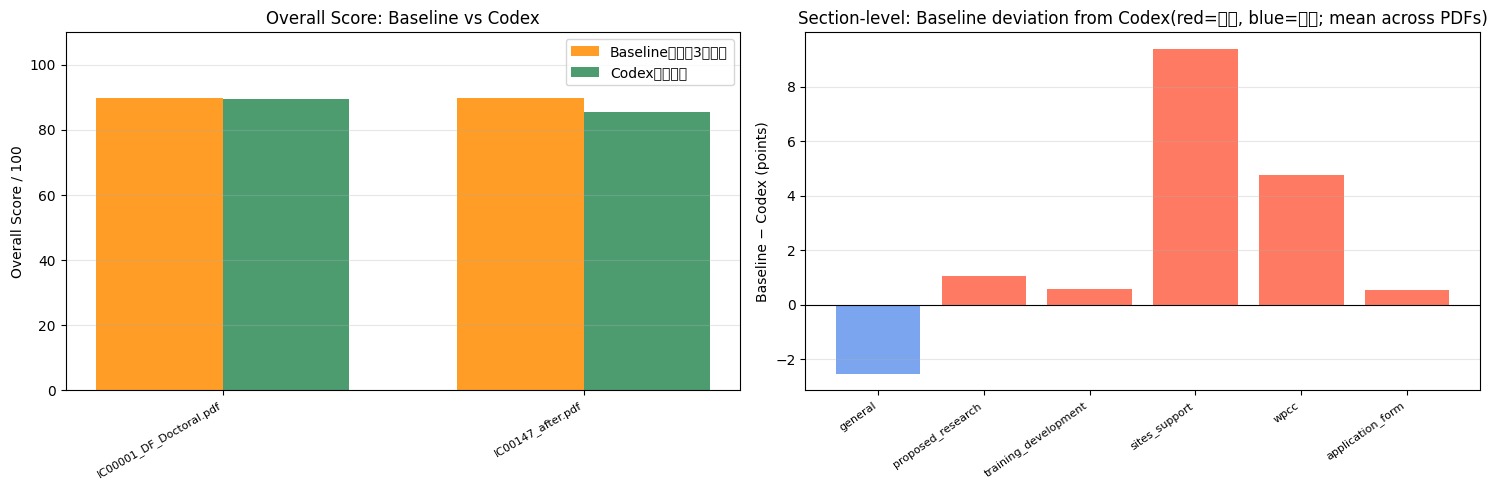

── MAE & Bias 汇总（overall_score_100）──
  Baseline vs Codex: MAE=2.30  bias=+2.30 (正=baseline偏高, 负=偏低)
数据来源: baseline_runs_20260413_114452.csv  +  2 个 codex JSON


In [7]:
# ── Cell E：Baseline vs Codex 双方对比（直接读最新 CSV，不依赖实验1 pipeline）──
# 自动找 results/ 下最新的 baseline_runs_*.csv，与 codex_scores/ 下的 JSON 做对比。
# 无需重跑任何 LLM，直接使用已保存结果。

import glob as _glob

# ── 1. 加载最新 baseline CSV ──────────────────────────────────────────────────
baseline_csvs = sorted(_glob.glob(str(RESULTS_DIR / 'baseline_runs_*.csv')))
if not baseline_csvs:
    raise FileNotFoundError(f'未找到 baseline_runs_*.csv，请先运行实验3')

latest_csv = baseline_csvs[-1]
print(f'读取最新 baseline CSV: {Path(latest_csv).name}')
bl_raw = pd.read_csv(latest_csv)

# 按 pdf_name 取均值（多次 run 平均）
score_cols_csv = ['overall_score_100'] + [f'{k}_score_100' for k in BASELINE_SECTION_KEYS]
score_cols_csv = [c for c in score_cols_csv if c in bl_raw.columns]
bl_mean = bl_raw.groupby('pdf_name')[score_cols_csv].mean().reset_index()
print(f'共 {len(bl_mean)} 个 PDF，每个 PDF 均值取自 {len(bl_raw) // len(bl_mean)} 次 run')
print()

# ── 2. 加载 Codex JSON，聚合得到 section 分 ──────────────────────────────────
rubric_sections_e = load_rubric(CRITERIA_PATH)
codex_rows_e = []
codex_files_e = sorted(CODEX_SCORES_DIR.glob('*_codex.json'))
if not codex_files_e:
    raise FileNotFoundError(f'{CODEX_SCORES_DIR} 中未找到 *_codex.json')

for fpath in codex_files_e:
    data = json.loads(fpath.read_text(encoding='utf-8'))
    doc_id = data.get('doc_id', fpath.stem.replace('_codex', ''))
    sub_scores = data.get('sub_scores', {})

    doc_type = ''
    pcp = PARSED_CACHE_DIR / f'{doc_id}.json'
    if pcp.exists():
        try:
            doc_type = (json.loads(pcp.read_text(encoding='utf-8')).get('doc_type') or '').lower()
        except Exception:
            pass

    features, overall, avg_sub = _aggregate_baseline(sub_scores, rubric_sections_e, doc_type)
    row = {
        'pdf_name': f'{doc_id}.pdf',
        'codex_overall': float(overall.get('final_score_0to100', 0)),
    }
    for k in BASELINE_SECTION_KEYS:
        sec = features.get(k, {})
        row[f'codex_{k}'] = float(sec.get('overall', {}).get('final_score_0to100', 0))
    codex_rows_e.append(row)
    print(f'  Codex {doc_id}: overall={row["codex_overall"]:.1f}')

codex_df_e = pd.DataFrame(codex_rows_e)
print()

# ── 3. 合并 & 计算偏差 ─────────────────────────────────────────────────────────
merged_e = bl_mean.merge(codex_df_e, on='pdf_name', how='inner')
merged_e['diff_overall'] = merged_e['overall_score_100'] - merged_e['codex_overall']
for k in BASELINE_SECTION_KEYS:
    bc = f'{k}_score_100'
    cc = f'codex_{k}'
    if bc in merged_e.columns and cc in merged_e.columns:
        merged_e[f'diff_{k}'] = merged_e[bc] - merged_e[cc]

print('── Baseline vs Codex 对比（baseline 为多次 run 均值）──')
disp = merged_e[['pdf_name', 'overall_score_100', 'codex_overall', 'diff_overall']].copy()
disp.columns = ['PDF', 'Baseline Overall', 'Codex Overall', 'Diff (B−C)']
display(disp)

# ── 4. 可视化 ──────────────────────────────────────────────────────────────────
if plt is not None:
    pdf_names_e = merged_e['pdf_name'].tolist()
    x_e = list(range(len(pdf_names_e)))
    w_e = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 图1：overall 双方柱状图
    for idx, (label, col, color) in enumerate([
        ('Baseline（实验3均值）', 'overall_score_100', 'darkorange'),
        ('Codex（参考）',         'codex_overall',     'seagreen'),
    ]):
        if col in merged_e.columns:
            axes[0].bar(
                [i + (idx - 0.5) * w_e for i in x_e],
                merged_e[col], w_e, label=label, color=color, alpha=0.85,
            )
    axes[0].set_xticks(x_e)
    axes[0].set_xticklabels(pdf_names_e, rotation=30, ha='right', fontsize=8)
    axes[0].set_ylabel('Overall Score / 100')
    axes[0].set_ylim(0, 110)
    axes[0].set_title('Overall Score: Baseline vs Codex')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # 图2：各 section 与 Codex 的偏差（mean across PDFs）
    section_data_e = []
    for k in BASELINE_SECTION_KEYS:
        dc = f'diff_{k}'
        if dc in merged_e.columns:
            section_data_e.append((k, merged_e[dc].mean()))
    if section_data_e:
        keys_e, diffs_e = zip(*section_data_e)
        xi_e = list(range(len(keys_e)))
        colors_e = ['tomato' if d > 0 else 'cornflowerblue' for d in diffs_e]
        axes[1].bar(xi_e, diffs_e, color=colors_e, alpha=0.85)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_xticks(xi_e)
        axes[1].set_xticklabels(keys_e, rotation=35, ha='right', fontsize=8)
        axes[1].set_ylabel('Baseline − Codex (points)')
        axes[1].set_title('Section-level: Baseline deviation from Codex(red=偏高, blue=偏低; mean across PDFs)')
        axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── 5. MAE 汇总 ────────────────────────────────────────────────────────────────
print('── MAE & Bias 汇总（overall_score_100）──')
mae_e  = merged_e['diff_overall'].abs().mean()
bias_e = merged_e['diff_overall'].mean()
print(f'  Baseline vs Codex: MAE={mae_e:.2f}  bias={bias_e:+.2f} (正=baseline偏高, 负=偏低)')

print(f'数据来源: {Path(latest_csv).name}  +  {len(codex_files_e)} 个 codex JSON')


Pipeline: 共扫描到 2 个 scored.json
               pdf_name                                                            run_file  pipeline_overall
IC00001_DF_Doctoral.pdf IC00001_DF_Doctoral_same_pdf_IC00001_DF_Doctoral_run_01_scored.json              91.2
IC00001_DF_Doctoral.pdf IC00001_DF_Doctoral_same_pdf_IC00001_DF_Doctoral_run_02_scored.json              88.1

Baseline CSV: baseline_runs_20260413_114452.csv

Codex IC00001_DF_Doctoral: overall=89.4
Codex IC00147_after: overall=85.6

── 三方 Overall 对比（NaN = 该 PDF 无 pipeline 结果）──


,PDF,Pipeline,Baseline,Codex,Pipe-Codex,Base-Codex
0,IC00001_DF_Doctoral.pdf,89.6,89.7,89.4,0.2,0.3
1,IC00147_after.pdf,NaN,89.9,85.6,NaN,4.3


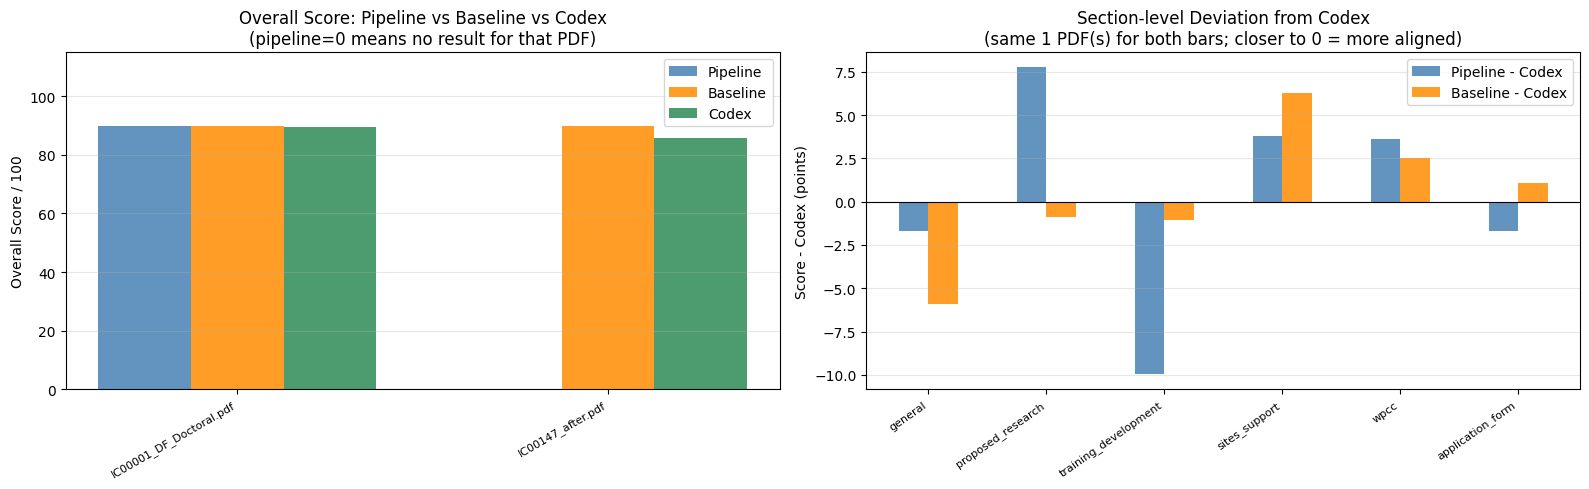


── MAE & Bias vs Codex ──
   三方共同 PDF（1 个）：
  Pipeline: MAE=0.25  bias=+0.25 (正=偏高, 负=偏低)
  Baseline: MAE=0.33  bias=+0.33 (正=偏高, 负=偏低)
   Baseline 全量（2 个 PDF，含无 pipeline 结果的）：
  Baseline: MAE=2.30  bias=+2.30

── Pipeline 各 run 明细 ──


,pdf_name,run_file,pipeline_overall
0,IC00001_DF_Doctoral.pdf,IC00001_DF_Doctoral_same_pdf_IC00001_DF_Doctor...,91.2
1,IC00001_DF_Doctoral.pdf,IC00001_DF_Doctoral_same_pdf_IC00001_DF_Doctor...,88.1



数据来源:
  Pipeline: 2 个 scored.json
  Baseline: baseline_runs_20260413_114452.csv
  Codex:    2 个 codex JSON


In [9]:
# ── Cell F：Pipeline(已有JSON) vs Baseline(CSV) vs Codex —— 三方离线对比 ─────
# 直接从磁盘读取已保存结果，无需重跑任何 LLM。
# - Pipeline: results/same_pdf_*_scored.json  (自动扫描所有 run)
# - Baseline: results/baseline_runs_*.csv 最新文件（多 run 均值）
# - Codex:    results/codex_scores/*_codex.json

import glob as _glob2

SECTION_KEYS_F = BASELINE_SECTION_KEYS

# ── 1. 读取 Pipeline scored JSON ─────────────────────────────────────────────
pipeline_rows_f = []
scored_pattern = str(RESULTS_DIR / 'same_pdf_*' / '*_scored.json')
scored_files = sorted(_glob2.glob(scored_pattern))
if not scored_files:
    raise FileNotFoundError(f'未找到 *_scored.json，路径: {scored_pattern}')

for fpath in scored_files:
    data = json.loads(Path(fpath).read_text(encoding='utf-8'))
    raw_doc_id = data.get('doc_id', '')
    pdf_stem = raw_doc_id.split('_same_pdf_')[0] if '_same_pdf_' in raw_doc_id else raw_doc_id
    pdf_name = f'{pdf_stem}.pdf'
    overall_score = float(data.get('overall', {}).get('final_score_0to100', 0))
    row = {'pdf_name': pdf_name, 'run_file': Path(fpath).name, 'pipeline_overall': overall_score}
    for k in SECTION_KEYS_F:
        sec = data.get('features', {}).get(k, {})
        row[f'pipeline_{k}'] = float(sec.get('overall', {}).get('final_score_0to100', 0))
    pipeline_rows_f.append(row)

pipeline_df_f = pd.DataFrame(pipeline_rows_f)
pipeline_mean_f = pipeline_df_f.groupby('pdf_name')[
    ['pipeline_overall'] + [f'pipeline_{k}' for k in SECTION_KEYS_F]
].mean().reset_index()
print(f'Pipeline: 共扫描到 {len(scored_files)} 个 scored.json')
print(pipeline_df_f[['pdf_name', 'run_file', 'pipeline_overall']].to_string(index=False))
print()

# ── 2. 读取 Baseline CSV（最新）─────────────────────────────────────────────
baseline_csvs_f = sorted(_glob2.glob(str(RESULTS_DIR / 'baseline_runs_*.csv')))
if not baseline_csvs_f:
    raise FileNotFoundError('未找到 baseline_runs_*.csv')
latest_csv_f = baseline_csvs_f[-1]
print(f'Baseline CSV: {Path(latest_csv_f).name}')
bl_f = pd.read_csv(latest_csv_f)
bl_score_cols = ['overall_score_100'] + [f'{k}_score_100' for k in SECTION_KEYS_F]
bl_score_cols = [c for c in bl_score_cols if c in bl_f.columns]
bl_mean_f = bl_f.groupby('pdf_name')[bl_score_cols].mean().reset_index()
bl_mean_f = bl_mean_f.rename(columns={
    'overall_score_100': 'baseline_overall',
    **{f'{k}_score_100': f'baseline_{k}' for k in SECTION_KEYS_F}
})
print()

# ── 3. 读取 Codex JSON ────────────────────────────────────────────────────────
rubric_f = load_rubric(CRITERIA_PATH)
codex_rows_f = []
for fpath in sorted(CODEX_SCORES_DIR.glob('*_codex.json')):
    data = json.loads(fpath.read_text(encoding='utf-8'))
    doc_id = data.get('doc_id', fpath.stem.replace('_codex', ''))
    sub_scores = data.get('sub_scores', {})
    doc_type = ''
    pcp = PARSED_CACHE_DIR / f'{doc_id}.json'
    if pcp.exists():
        try:
            doc_type = (json.loads(pcp.read_text(encoding='utf-8')).get('doc_type') or '').lower()
        except Exception:
            pass
    features_c, overall_c, _ = _aggregate_baseline(sub_scores, rubric_f, doc_type)
    row_c = {'pdf_name': f'{doc_id}.pdf',
             'codex_overall': float(overall_c.get('final_score_0to100', 0))}
    for k in SECTION_KEYS_F:
        sec_c = features_c.get(k, {})
        row_c[f'codex_{k}'] = float(sec_c.get('overall', {}).get('final_score_0to100', 0))
    codex_rows_f.append(row_c)
    print(f'Codex {doc_id}: overall={row_c["codex_overall"]:.1f}')
codex_df_f = pd.DataFrame(codex_rows_f)
print()

# ── 4. 三方合并 ───────────────────────────────────────────────────────────────
merged_f = (pipeline_mean_f
            .merge(bl_mean_f,  on='pdf_name', how='outer')
            .merge(codex_df_f, on='pdf_name', how='outer'))

for k_col in ['overall'] + list(SECTION_KEYS_F):
    pc, bc, cc = f'pipeline_{k_col}', f'baseline_{k_col}', f'codex_{k_col}'
    if pc in merged_f.columns and cc in merged_f.columns:
        merged_f[f'pdiff_{k_col}'] = merged_f[pc] - merged_f[cc]
    if bc in merged_f.columns and cc in merged_f.columns:
        merged_f[f'bdiff_{k_col}'] = merged_f[bc] - merged_f[cc]

print('── 三方 Overall 对比（NaN = 该 PDF 无 pipeline 结果）──')
disp_f = merged_f[['pdf_name', 'pipeline_overall', 'baseline_overall', 'codex_overall',
                    'pdiff_overall', 'bdiff_overall']].copy()
disp_f.columns = ['PDF', 'Pipeline', 'Baseline', 'Codex', 'Pipe-Codex', 'Base-Codex']
display(disp_f.round(1))

# ── 5. 可视化 ─────────────────────────────────────────────────────────────────
if plt is not None:
    # 图2 只用三方都有分数的 PDF，保证 Pipeline / Baseline 两组柱的样本集完全相同
    merged_common_f = merged_f.dropna(subset=['pipeline_overall', 'codex_overall'])
    n_common_f = len(merged_common_f)

    pdfs_f = merged_f['pdf_name'].tolist()
    x_f, w_f = list(range(len(pdfs_f))), 0.25

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # 图1：overall 三方柱状图（所有 PDF）
    for idx, (label, col, color) in enumerate([
        ('Pipeline', 'pipeline_overall', 'steelblue'),
        ('Baseline', 'baseline_overall', 'darkorange'),
        ('Codex',    'codex_overall',    'seagreen'),
    ]):
        if col in merged_f.columns:
            axes[0].bar([i + (idx - 1) * w_f for i in x_f],
                        merged_f[col].fillna(0), w_f, label=label, color=color, alpha=0.85)
    axes[0].set_xticks(x_f)
    axes[0].set_xticklabels(pdfs_f, rotation=30, ha='right', fontsize=8)
    axes[0].set_ylabel('Overall Score / 100')
    axes[0].set_ylim(0, 115)
    axes[0].set_title('Overall Score: Pipeline vs Baseline vs Codex\n(pipeline=0 means no result for that PDF)')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)

    # 图2：section 偏差 —— 仅用三方都有分数的 PDF，Pipeline/Baseline 样本集完全一致
    sec_labels, p_diffs_f, b_diffs_f = [], [], []
    for k in SECTION_KEYS_F:
        pd_col, bd_col = f'pdiff_{k}', f'bdiff_{k}'
        if pd_col in merged_common_f.columns and bd_col in merged_common_f.columns:
            sec_labels.append(k)
            p_diffs_f.append(merged_common_f[pd_col].mean())
            b_diffs_f.append(merged_common_f[bd_col].mean())
    if sec_labels:
        xi_f = list(range(len(sec_labels)))
        axes[1].bar([i - w_f/2 for i in xi_f], p_diffs_f, w_f,
                    label='Pipeline - Codex', color='steelblue', alpha=0.85)
        axes[1].bar([i + w_f/2 for i in xi_f], b_diffs_f, w_f,
                    label='Baseline - Codex', color='darkorange', alpha=0.85)
        axes[1].axhline(0, color='black', linewidth=0.8)
        axes[1].set_xticks(xi_f)
        axes[1].set_xticklabels(sec_labels, rotation=35, ha='right', fontsize=8)
        axes[1].set_ylabel('Score - Codex (points)')
        axes[1].set_title(
            f'Section-level Deviation from Codex\n'
            f'(same {n_common_f} PDF(s) for both bars; closer to 0 = more aligned)'
        )
        axes[1].legend()
        axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

# ── 6. MAE 汇总 ───────────────────────────────────────────────────────────────
merged_common_f = merged_f.dropna(subset=['pipeline_overall', 'codex_overall'])
print(f'\n── MAE & Bias vs Codex ──')
print(f'   三方共同 PDF（{len(merged_common_f)} 个）：')
for label, col in [('Pipeline', 'pdiff_overall'), ('Baseline', 'bdiff_overall')]:
    if col in merged_common_f.columns:
        valid = merged_common_f[col].dropna()
        if not valid.empty:
            print(f'  {label}: MAE={valid.abs().mean():.2f}  bias={valid.mean():+.2f} (正=偏高, 负=偏低)')

# Baseline 单独统计（可含更多 PDF）
merged_bl_only = merged_f.dropna(subset=['baseline_overall', 'codex_overall'])
if len(merged_bl_only) > len(merged_common_f):
    valid_b = merged_bl_only['bdiff_overall'].dropna()
    print(f'   Baseline 全量（{len(merged_bl_only)} 个 PDF，含无 pipeline 结果的）：')
    print(f'  Baseline: MAE={valid_b.abs().mean():.2f}  bias={valid_b.mean():+.2f}')

# ── 7. Per-run Pipeline 明细 ──────────────────────────────────────────────────
print('\n── Pipeline 各 run 明细 ──')
display(pipeline_df_f[['pdf_name', 'run_file', 'pipeline_overall']].round(1))

print(f'\n数据来源:')
print(f'  Pipeline: {len(scored_files)} 个 scored.json')
print(f'  Baseline: {Path(latest_csv_f).name}')
print(f'  Codex:    {len(codex_rows_f)} 个 codex JSON')


In [ ]:
# ── Cell D：三方对比可视化（pipeline / baseline / codex）──────────────────────────
# 依赖：same_pdf_df（实验1）、baseline_df（实验3）、codex_df（Cell C）都已在内存中。

try:
    assert not codex_df.empty, 'codex_df 为空'
    three_way = compare_all_three(same_pdf_df, baseline_df, codex_df)
    print('── Pipeline / Baseline / Codex 三方均值对比 ──')
    display(three_way)

    if plt is not None:
        pdf_names = three_way['pdf_name'].tolist()
        x = list(range(len(pdf_names)))
        w = 0.25

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # ── 图1：overall 三方柱状图 ─────────────────────────────────────────────
        for idx, (label, col, color) in enumerate([
            ('Pipeline（实验1）', 'pipeline_overall_score_100', 'steelblue'),
            ('Baseline（实验3）', 'baseline_overall_score_100', 'darkorange'),
            ('Codex（参考）',     'codex_overall_score_100',    'seagreen'),
        ]):
            if col in three_way.columns:
                axes[0].bar(
                    [i + (idx - 1) * w for i in x],
                    three_way[col], w, label=label, color=color,
                )
        axes[0].set_xticks(x)
        axes[0].set_xticklabels(pdf_names, rotation=30, ha='right', fontsize=8)
        axes[0].set_ylabel('Overall Score / 100')
        axes[0].set_title('Overall Score: Pipeline vs Baseline vs Codex')
        axes[0].legend()
        axes[0].grid(axis='y', alpha=0.3)

        # ── 图2：各 section 与 Codex 的偏差（mean across PDFs）─────────────────
        section_data = []
        for key in BASELINE_SECTION_KEYS:
            p_col = f'pipeline_vs_codex_{key}_score_100'
            b_col = f'baseline_vs_codex_{key}_score_100'
            if p_col in three_way.columns and b_col in three_way.columns:
                section_data.append((key, three_way[p_col].mean(), three_way[b_col].mean()))
        if section_data:
            keys_, p_diffs, b_diffs = zip(*section_data)
            xi = list(range(len(keys_)))
            axes[1].bar([i - w/2 for i in xi], p_diffs, w,
                        label='Pipeline − Codex', color='steelblue')
            axes[1].bar([i + w/2 for i in xi], b_diffs, w,
                        label='Baseline − Codex', color='darkorange')
            axes[1].axhline(0, color='black', linewidth=0.8)
            axes[1].set_xticks(xi)
            axes[1].set_xticklabels(keys_, rotation=35, ha='right', fontsize=8)
            axes[1].set_ylabel('Score difference vs Codex')
            axes[1].set_title('Section-level Deviation from Codex\n(closer to 0 = more aligned with Codex)')
            axes[1].legend()
            axes[1].grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()

    # ── MAE 汇总 ───────────────────────────────────────────────────────────────
    print('\n── 与 Codex 的 MAE（Mean Absolute Error, overall_score_100）──')
    for label, col in [
        ('Pipeline（实验1）', 'pipeline_vs_codex_overall_score_100'),
        ('Baseline（实验3）', 'baseline_vs_codex_overall_score_100'),
    ]:
        if col in three_way.columns:
            mae = three_way[col].abs().mean()
            bias = three_way[col].mean()
            print(f'  {label}: MAE={mae:.2f}  bias={bias:+.2f} (正=偏高, 负=偏低)')

except (AssertionError, NameError) as e:
    print(f'跳过：{e}')
    print('请确保 same_pdf_df（实验1）、baseline_df（实验3）、codex_df（Cell C）都已运行。')
